In [ ]:
from langgraph.graph import StateGraph,START,END
from langchain_mistralai import ChatMistralAI
from langchain_core.prompts import ChatPromptTemplate
from dotenv import load_dotenv

from datetime import datetime
from dateutil.parser import parse

from prompts import System_prompt,Human_prompt
from langgraph.types import interrupt

from langgraph.checkpoint.memory import MemorySaver

load_dotenv()

True

In [68]:
stage_values = {
    "1st Follow-Up": {
        "followup_number": 1,
        "tone": "Warm & Friendly",
        "key_message": "Gentle reminder, assume oversight",
        "cta": "Pay now using the payment link below",
        "escalation_required": False,
    },

    "2nd Follow-Up": {
        "followup_number": 2,
        "tone": "Polite but Firm",
        "key_message": "Payment still pending; request confirmation",
        "cta": "Please confirm your payment date",
        "escalation_required": False,
    },

    "3rd Follow-Up": {
        "followup_number": 3,
        "tone": "Formal & Serious",
        "key_message": "Escalating concern; mention impact",
        "cta": "Please respond within 48 hours",
        "escalation_required": False,
    },

    "4th Follow-Up": {
        "followup_number": 4,
        "tone": "Stern & Urgent",
        "key_message": "Final reminder before escalation",
        "cta": "Pay immediately or contact us",
        "escalation_required": False,
    },

    "Escalation Flag": {
        "followup_number": 5,
        "tone": "Legal Review Required",
        "key_message": "Human review required; no automatic email",
        "cta": "Assign to finance manager",
        "escalation_required": True,
    }
}

In [69]:
from typing import TypedDict, Literal, Optional, Any
from pydantic import BaseModel, Field, EmailStr


class EmailDraft(BaseModel):
    recipient: EmailStr = Field(description="Recipient email")
    subject: str = Field(description="Email subject")
    body: str = Field(description="Email body")
    tone: Literal[
        "Warm & Friendly",
        "Polite but Firm",
        "Formal & Serious",
        "Stern & Urgent",
        "Legal Review Required",
    ] = Field(description="Tone used in the email")


class InvoiceData(TypedDict):
    invoice_no: str
    client: str
    amount: float
    due_date: str
    contact_email: str
    followup_count: int


class StageMeta(TypedDict):
    followup_number: int = Field(ge=1, le=5)
    tone: Literal[
        "Warm & Friendly",
        "Polite but Firm",
        "Formal & Serious",
        "Stern & Urgent",
        "Legal Review Required",
    ]
    key_message: str
    cta: str
    escalation_required: bool


class AgentState(TypedDict):
    # Input invoice
    invoice: InvoiceData

    # Derived information
    days_overdue: int
    stage_key: Literal[
        "1st Follow-Up",
        "2nd Follow-Up",
        "3rd Follow-Up",
        "4th Follow-Up",
        "Escalation Flag",
    ]
    stage_meta: StageMeta

    # Payment
    payment_link: str

    # LLM output
    email_draft: Optional[EmailDraft]

    # Validation
    validation_status: Literal["approved", "rejected"]
    validation_feedback: str

    # Retry control
    retry_count: int
    max_retries: int

    # Escalation
    escalation_required: bool

    # Email sending
    send_status: Literal["pending", "sent", "failed", "not_sent"]
    send_error: str

    # Audit log (stored in DB or JSON)
    audit_log: dict[str, Any]

In [70]:
model = ChatMistralAI(temperature=0.1)
email_agent = model.with_structured_output(EmailDraft)

In [ ]:
def get_overdue_days(state : AgentState) -> AgentState:
    
    due_date = state["invoice"]["due_date"]

    if (not due_date):
        print("No due date found in invoice data")
        return state

    try :
        due_date = parse(
            timestr = str(due_date),
            dayfirst = True
        ).date()
        today = datetime.today().date()
        days_overdue = max((today - due_date).days,0)
        return {**state, "days_overdue": days_overdue}
    
    except Exception as e :
        print(f"Invalid date format: {due_date}")
        return state
    
def set_stage(state : AgentState) -> AgentState:
    days = state["days_overdue"]

    if 1 <= days <= 7:
        stage = "1st Follow-Up"

    elif 8 <= days <= 14:
        stage = "2nd Follow-Up"

    elif 15 <= days <= 21:
        stage = "3rd Follow-Up"

    elif 22 <= days <= 30:
        stage = "4th Follow-Up"

    else:
        stage = "Escalation Flag"

    return {
        "stage_key": stage,
        "stage_meta": {**stage_values[stage]}
    }

def check_overdue (state : AgentState) -> Literal["escalation","generate_email_draft"]:
    if (state["days_overdue"] > 30):
        return "escalation"
    else:
        return "generate_email_draft"
    
def escalation_node(state: AgentState) -> AgentState:
    return {"escalation_required": True}    
    

In [72]:
def generate_payment_link(invoice_no: str) -> str:
    return f"https://pay.company.com/{invoice_no}"


def generate_email_draft(state: AgentState) -> AgentState:
    invoice = state["invoice"]
    stage_meta = state["stage_meta"]

    payment_link = state.get("payment_link")
    if not payment_link:
        payment_link = generate_payment_link(invoice["invoice_no"])

    prompt = ChatPromptTemplate.from_messages(
        [
            ("system", System_prompt),
            ("human", Human_prompt),
        ]
    )

    email_generation_chain = prompt | email_agent

    details = {
        # Invoice details
        "client_name": invoice["client"],
        "recipient_email": invoice["contact_email"],
        "invoice_id": invoice["invoice_no"],
        "amount": invoice["amount"],
        "due_date": invoice["due_date"],
        "days_overdue": state["days_overdue"],

        # Stage details
        "stage": state["stage_key"],
        "tone": stage_meta["tone"],
        "key_message": stage_meta["key_message"],
        "cta": stage_meta["cta"],

        # Payment information
        "payment_link": payment_link,
        "finance_contact": "finance@company.com",

        # Validation feedback for retry
        "validation_feedback": state.get("validation_feedback", "None"),
    }

    email_draft = email_generation_chain.invoke(details)

    return {
        **state,
        "payment_link": payment_link,
        "email_draft": email_draft,
    }

In [ ]:
def validate_draft_email(state: AgentState) -> AgentState:
    validation_status = "approved"
    validation_feedback = ""

    stage_meta = state["stage_meta"]
    email_draft = state.get("email_draft")
    invoice = state["invoice"]

    if not email_draft:
        validation_status = "rejected"
        validation_feedback = "No email draft generated."

    elif (
        str(email_draft.recipient).strip().lower()
        != invoice["contact_email"].strip().lower()
    ):
        validation_status = "rejected"
        validation_feedback = (
            "Recipient email does not match invoice contact email."
        )

    elif email_draft.tone.strip() != stage_meta["tone"].strip():
        validation_status = "rejected"
        validation_feedback = (
            f"Tone must be exactly '{stage_meta['tone']}'."
        )

    elif invoice["invoice_no"] not in email_draft.subject:
        validation_status = "rejected"
        validation_feedback = (
            "Subject must include the invoice number."
        )

    else:
        body = email_draft.body

        required_values = [
            invoice["client"],
            invoice["invoice_no"],
            str(invoice["amount"]),
            str(invoice["due_date"]),
            str(state["days_overdue"]),
            state["payment_link"],
        ]

        for value in required_values:
            if str(value) not in body:
                validation_status = "rejected"
                validation_feedback = (
                    f"Email body must include: {value}"
                )
                break

    retry_count = state.get("retry_count", 0)
    if validation_status == "rejected":
        retry_count += 1

    user_decision = interrupt(
    {
        "type": "approval_request",
        "title": "Review Generated Payment Follow-Up Email",
        "message": (
            "Please review the generated email draft.\n\n"
            "Choose one of the following actions:\n"
            "1. approve  -> Accept the email and continue to audit logging.\n"
            "2. reject   -> Provide feedback so the AI can regenerate the email.\n\n"
            "If you reject the draft, include specific feedback such as:\n"
            "- Subject should be more formal\n"
            "- Mention invoice amount more clearly\n"
            "- Tone is too aggressive\n"
            "- Add stronger call to action"
        ),
        "invoice_details": {
            "invoice_no": invoice["invoice_no"],
            "client": invoice["client"],
            "amount": invoice["amount"],
            "due_date": invoice["due_date"],
            "days_overdue": state["days_overdue"],
            "stage": state["stage_key"],
        },
        "email_preview": {
            "recipient": str(email_draft.recipient),
            "subject": email_draft.subject,
            "body": email_draft.body,
            "tone": email_draft.tone,
        },
        "expected_response_format": {
            "decision": "approve | reject",
            "feedback": "Optional. Required only when decision is reject."
        }
    }
)

    if user_decision["decision"] == "reject":
        validation_status = "rejected"
        validation_feedback = user_decision.get(
            "feedback",
            "User requested changes to the email draft."
        )
        retry_count += 1
    else:
        validation_status = "approved"
        validation_feedback = ""

    return {
        "validation_status": validation_status,
        "validation_feedback": validation_feedback,
        "retry_count": retry_count,
    }


def check_validation(
    state: AgentState,
) -> Literal["auditLog", "generate_email_draft", "escalation"]:
    if state["validation_status"] == "approved":
        return "auditLog"

    if state["retry_count"] >= state["max_retries"]:
        return "escalation"

    return "generate_email_draft"

In [74]:
def mask_email(email: str) -> str:
    if not email or "@" not in email:
        return ""

    local, domain = email.split("@", 1)

    if len(local) <= 2:
        masked_local = local[0] + "*"
    else:
        masked_local = local[:2] + "*" * (len(local) - 2)

    return f"{masked_local}@{domain}"


def auditLog(state: AgentState) -> AgentState:
    invoice = state["invoice"]
    stage_meta = state.get("stage_meta")
    email_draft = state.get("email_draft")

    recipient = ""
    subject = ""
    tone = ""

    # email_draft is a Pydantic EmailDraft object
    if email_draft:
        recipient = str(email_draft.recipient)
        subject = email_draft.subject
        tone = email_draft.tone

    audit_log = {
        "timestamp": datetime.utcnow().isoformat() + "Z",

        # Invoice details (matches InvoiceData TypedDict)
        "invoice_no": invoice["invoice_no"],
        "client": invoice["client"],
        "amount": invoice["amount"],
        "due_date": invoice["due_date"],
        "contact_email": mask_email(invoice["contact_email"]),
        "followup_count": invoice["followup_count"],

        # Derived workflow details
        "days_overdue": state.get("days_overdue"),
        "stage_key": state.get("stage_key"),

        # Stage metadata (matches StageMeta TypedDict)
        "followup_number": (
            stage_meta["followup_number"] if stage_meta else None
        ),
        "tone_used": (
            tone if tone else (
                stage_meta["tone"] if stage_meta else None
            )
        ),
        "key_message": (
            stage_meta["key_message"] if stage_meta else None
        ),
        "cta": (
            stage_meta["cta"] if stage_meta else None
        ),
        "escalation_required": (
            stage_meta["escalation_required"] if stage_meta else False
        ),

        # Payment information
        "payment_link": state.get("payment_link"),

        # Generated email details
        "recipient": mask_email(recipient),
        "subject": subject,

        # Validation details
        "validation_status": state.get("validation_status"),
        "validation_feedback": state.get("validation_feedback", ""),

        # Retry information
        "retry_count": state.get("retry_count", 0),
        "max_retries": state.get("max_retries", 0),

        # Sending information
        "send_status": state.get("send_status", "not_sent"),
        "send_error": state.get("send_error", ""),

        # Summary flags
        "email_generated": email_draft is not None,
    }

    # TODO:
    # save_to_sqlite(audit_log)
    # save_to_json(audit_log)

    return {
        **state,
        "audit_log": audit_log,
    }

In [ ]:
checkpointer = MemorySaver()
graph = StateGraph(AgentState)

graph.add_node("get_overdue_days", get_overdue_days)
graph.add_node("set_stage", set_stage)
graph.add_node("escalation", escalation_node)
graph.add_node("generate_email_draft", generate_email_draft)
graph.add_node("validate_draft_email", validate_draft_email)
graph.add_node("auditLog", auditLog)

graph.add_edge(START, "get_overdue_days")
graph.add_edge("get_overdue_days", "set_stage")

# Route based on overdue days
graph.add_conditional_edges("set_stage", check_overdue)

# IMPORTANT: After email generation, validate it
graph.add_edge("generate_email_draft", "validate_draft_email")

# Escalated invoices are also logged
graph.add_edge("escalation", "auditLog")

# Validation routing
graph.add_conditional_edges("validate_draft_email", check_validation)

# Final step
graph.add_edge("auditLog", END)

agent = graph.compile(checkpointer=checkpointer)

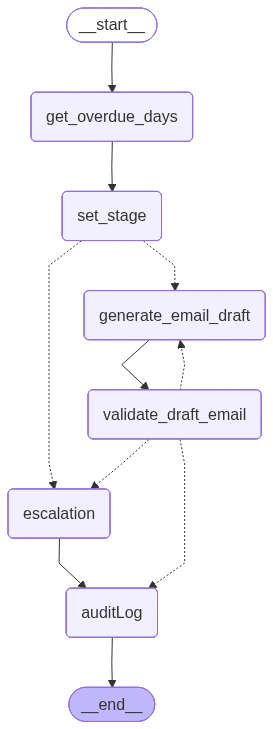

In [76]:
from IPython.display import Image
Image(agent.get_graph().draw_mermaid_png())